# Velocity Outflow Investigation

In [1]:
import LineLocking_FinalVersion as LineLocking
from astropy.table import Table
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import rc
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from tqdm.notebook import tqdm
from scipy.optimize import fsolve
from matplotlib.ticker import AutoMinorLocator
from scipy.optimize import curve_fit
from scipy.integrate import simpson  # or trapezoid


# Create and Sort the Stacks

In [2]:
species = 'CIV'
blue_line = 1548.20
red_line = 1550.77

save_file = "Final_N" #"Final_N_Model"
data = pd.read_csv(f"/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cuts/LineLocking_Stats_{save_file}.csv")
stacking_spectra_data = np.loadtxt(f'/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cuts/stacking_spectra_{save_file}.csv', delimiter=',')
num_of_spectra = len(stacking_spectra_data)

# Re sort the data
sorted_indices = np.argsort(data['Outflow Speeds'].to_numpy())
outflow_speeds = data['Outflow Speeds'].to_numpy()[sorted_indices]
weights = data['Weights'].to_numpy()[sorted_indices]
stacking_spectra = stacking_spectra_data[sorted_indices]
stacking_wavelengths = np.arange(900.2, 1599.8, 0.3)

def nanweighted_mean_std(data, weights, axis=0):
    data = np.asarray(data)
    weights = np.asarray(weights)

    # Expand weights to match data dimensions along the averaging axis
    if axis == 0 and weights.ndim == 1:
        weights = weights[:, np.newaxis]
    elif axis == 1 and weights.ndim == 1:
        weights = weights[np.newaxis, :]

    # Mask NaNs
    mask = ~np.isnan(data)
    safe_data = np.where(mask, data, 0)
    safe_weights = np.where(mask, weights, 0)

    # Compute weighted mean
    weighted_sum = np.sum(safe_data * safe_weights, axis=axis)
    sum_weights = np.sum(safe_weights, axis=axis)
    with np.errstate(divide='ignore', invalid='ignore'):
        mean = np.divide(weighted_sum, sum_weights)
        mean[sum_weights == 0] = np.nan

    # Expand mean back to data shape for broadcasting
    mean_broadcast = np.expand_dims(mean, axis=axis)
    squared_diff = (safe_data - mean_broadcast) ** 2

    # Compute weighted standard deviation
    weighted_squared_diff = squared_diff * safe_weights
    variance = np.sum(weighted_squared_diff, axis=axis) / sum_weights
    std = np.sqrt(variance)
    std[sum_weights == 0] = np.nan

    return mean, std


## Create a function to model the CIV Triplet, and an arbitrary Doublet

In [4]:
Delta = 0.5     # Width of the absorption lines
C = 0.9         # Cover fraction
xc = 0.01       # Contamination Fraction

def beta(lam):
    global Delta
    return np.exp(-(lam-1548.20)**2/(2*Delta**2))
def alpha(lam):
    global Delta
    return np.exp(-(lam-1550.77)**2/(2*Delta**2))
def gamma(lam):
    global Delta
    return np.exp(-(lam-1545.63)**2/(2*Delta**2))

# Define the system of equations
def CIV_system_of_equations(vars):
    x, B, R = vars
    global C
    # Wavelengths of the blue line, red line, and violet line respectively
    lb = 1548.20
    lr = 1550.77
    lv = 1545.63

    # 3 equations that comprise the system of equations
    eq1 = x*C*B**(beta(lb))*R**(alpha(lb))*B**(gamma(lb))*R**(beta(lb))-(x+xc-1)*C*B**(beta(lb))*R**(alpha(lb))+xc*C*B**(gamma(lb))*R**(beta(lb))+1-C-measured_b
    eq2 = x*C*B**(beta(lr))*R**(alpha(lr))*B**(gamma(lr))*R**(beta(lr))-(x+xc-1)*C*B**(beta(lr))*R**(alpha(lr))+xc*C*B**(gamma(lr))*R**(beta(lr))+1-C-measured_r
    eq3 = x*C*B**(beta(lv))*R**(alpha(lv))*B**(gamma(lv))*R**(beta(lv))-(x+xc-1)*C*B**(beta(lv))*R**(alpha(lv))+xc*C*B**(gamma(lv))*R**(beta(lv))+1-C-measured_v
    return [eq1, eq2, eq3]

def get_depths(rBar, bBar, C, Delta, lr, lb):
    alpha = -(lr-lb)**2/(2*Delta**2)
    tb = (np.log((bBar-1+C)/C)-np.exp(alpha)*np.log((rBar-1+C)/C))/(np.exp(2*alpha)-1)
    tr = -tb*np.exp(alpha)-np.log((rBar-1+C)/C)
    return tb, tr


def get_absorption_reduction(tb, tr, verbose=False):
    Delta = 0.8     # Width of the absorption lines
    C = 0.9         # Cover fraction
    lb = 1548.20
    lr = 1550.77
    lv = 1545.63

    l = np.linspace(1542, 1554, 10000)  # high-res grid covering your lines

    def I1_func(l, tb, tr):
        return -C+C*np.exp(-tb*np.exp(-(l-lb)**2/(2*Delta**2))-tr*np.exp(-(l-lr)**2/(2*Delta**2)))
    def I2_func(l, tb, tr):
        return -C+C*np.exp(-tb*np.exp(-(l-lb)**2/(2*Delta**2))-tr*np.exp(-(l-lr)**2/(2*Delta**2))-tb*np.exp(-(l-lv)**2/(2*Delta**2))-tr*np.exp(-(l-lb)**2/(2*Delta**2)))

    I1 = I1_func(l, tb, tr)
    I2 = I2_func(l, tb, tr)
    area_I1 = simpson(I1, l)*-1
    area_I2 = simpson(I2, l)*-1
    if verbose:
        print(1-(area_I2-area_I1)/area_I1)

        plt.plot(l, I2_func(l, tb, tr))
        plt.plot(l, I1_func(l, tb, tr))
    return 1-(area_I2-area_I1)/area_I1


## Sweep the Window Across Data for CIV

In [10]:
window_size = 3000
shift = 10
velocities = []

########### CIV Variables ############
CIV_densities = []
CIV_ratios = []
CIV_tau = []
CIV_fractions = []
CIV_reduction = []
# Get the wavelength array
CIV_wlMin = np.argmin(np.abs(stacking_wavelengths-(1548.2-25*0.3)))
CIV_wlMax = np.argmin(np.abs(stacking_wavelengths-(1548.2+25*0.3)))
CIV_wls = stacking_wavelengths[CIV_wlMin:CIV_wlMax]

########### OVI Variables ############
OVI_tau = []
OVI_densities = []
# Get the wavelength array
OVI_wlMin = np.argmin(np.abs(stacking_wavelengths-(1037.616-25*0.3)))
OVI_wlMax = np.argmin(np.abs(stacking_wavelengths-(1037.616+25*0.3)))
OVI_wls = stacking_wavelengths[OVI_wlMin:OVI_wlMax]

########### NV Variables ############
NV_densities = []
# Get the wavelength array
NV_wlMin = np.argmin(np.abs(stacking_wavelengths-(1242.804-50*0.3)))
NV_wlMax = np.argmin(np.abs(stacking_wavelengths-(1242.804+50*0.3)))
NV_wls = stacking_wavelengths[NV_wlMin:NV_wlMax]

########### HI Variables ############
HI_densities = []
# Get the wavelength array
HI_wlMin = np.argmin(np.abs(stacking_wavelengths-(1215.670-25*0.3)))
HI_wlMax = np.argmin(np.abs(stacking_wavelengths-(1215.670+25*0.3)))
HI_wls = stacking_wavelengths[HI_wlMin:HI_wlMax]

for k in tqdm(range(int((num_of_spectra-window_size)/shift))):
    indices = np.arange(0, window_size)+k*shift

    current_CIV_stacking_spectra = []
    current_OVI_stacking_spectra = []
    current_NV_stacking_spectra = []
    current_HI_stacking_spectra = []
    current_outflow_speeds = []
    current_weights = []
    for idx in indices:
        current_CIV_stacking_spectra.append(stacking_spectra[idx][CIV_wlMin:CIV_wlMax])
        current_OVI_stacking_spectra.append(stacking_spectra[idx][OVI_wlMin:OVI_wlMax])
        current_NV_stacking_spectra.append(stacking_spectra[idx][NV_wlMin:NV_wlMax])
        current_HI_stacking_spectra.append(stacking_spectra[idx][HI_wlMin:HI_wlMax])
        current_outflow_speeds.append(outflow_speeds[idx])
        current_weights.append(weights[idx])

    # Stack the spectra
    CIV_stack, _ = nanweighted_mean_std(current_CIV_stacking_spectra, current_weights, axis=0)
    OVI_stack, _ = nanweighted_mean_std(current_OVI_stacking_spectra, current_weights, axis=0)
    NV_stack, _ = nanweighted_mean_std(current_NV_stacking_spectra, current_weights, axis=0)
    HI_stack, _ = nanweighted_mean_std(current_HI_stacking_spectra, current_weights, axis=0)

    # Perform CIV Measurments
    measured_b = np.interp(1548.20, CIV_wls, CIV_stack)
    measured_r = np.interp(1550.77, CIV_wls, CIV_stack)
    measured_v = np.interp(1545.63, CIV_wls, CIV_stack)
    initial_guess = [0.65, 0.36, 0.5]
    solutions = fsolve(CIV_system_of_equations, initial_guess)
    CIV_ratios.append(np.log(solutions[1])/np.log(solutions[2]))
    CIV_tau.append(-np.log(solutions[2]))
    CIV_fractions.append(solutions[0])
    CIV_densities.append(LineLocking.column_density_from_tau(-np.log(solutions[2]), 1551).value)
    CIV_reduction.append(get_absorption_reduction(-np.log(solutions[1]), -np.log(solutions[2]), verbose=False))

    # Perform OVI Measurments
    OVI_bBar = np.interp(1031.926, OVI_wls, OVI_stack)
    OVI_rBar = np.interp(1037.616, OVI_wls, OVI_stack)
    OVI_tb, OVI_tr = get_depths(OVI_rBar, OVI_bBar, C, Delta, 1037.616, 1031.926)
    OVI_tau.append(OVI_tr)
    OVI_densities.append(LineLocking.column_density_from_tau(OVI_tr, 1038).value)

    # Perform NV Measurments
    NV_bBar = np.interp(1238.821, NV_wls, NV_stack)
    NV_rBar = np.interp(1242.804, NV_wls, NV_stack)
    NV_tb, NV_tr = get_depths(NV_rBar, NV_bBar, C, Delta, 1242.804, 1238.821)
    NV_densities.append(LineLocking.column_density_from_tau(NV_tr, 1243).value)


     # Perform HI Measurments
    HI_bBar = np.interp(1215.670, HI_wls, HI_stack)
    HI_tb = -np.log((HI_bBar-1+C)/C)
    HI_densities.append(LineLocking.column_density_from_tau(HI_tb, 1216).value)


    velocities.append(np.average(current_outflow_speeds, weights=current_weights))



  0%|          | 0/2633 [00:00<?, ?it/s]

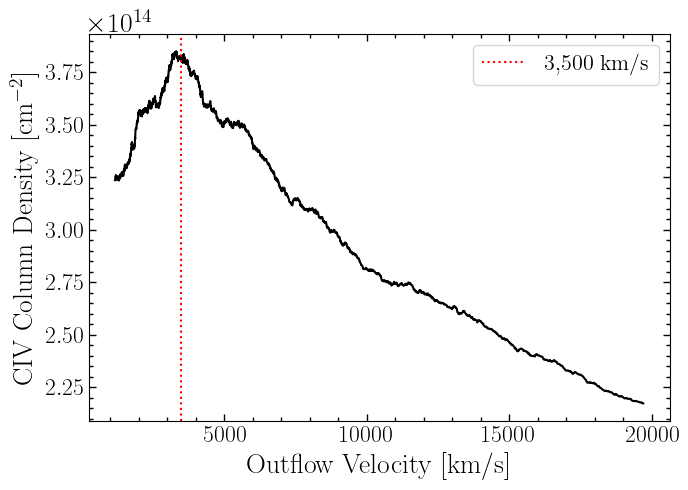

In [11]:
labelsize = 20
ticksize = 15
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(velocities, CIV_densities, 'k-')
ax.axvline(x=3500, color='r', linestyle=':', label='3,500 km/s')
ax.set_ylabel(r'CIV Column Density [cm$^{-2}$]', fontsize=labelsize)
ax.set_xlabel(r'Outflow Velocity [km/s]', fontsize=labelsize)
ax.tick_params(axis='both', which='major', direction='in', top=True, right=True,
               length=5, width=1, labelsize=ticksize+2)
ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
               length=3, width=1)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax.yaxis.offsetText.set_fontsize(labelsize)
plt.tight_layout()
plt.legend(fontsize=labelsize-4)
plt.savefig("./Results/Figures/Density_vs_Velocity.png", bbox_inches="tight", dpi=300)
#plt.xscale('log')
plt.show()

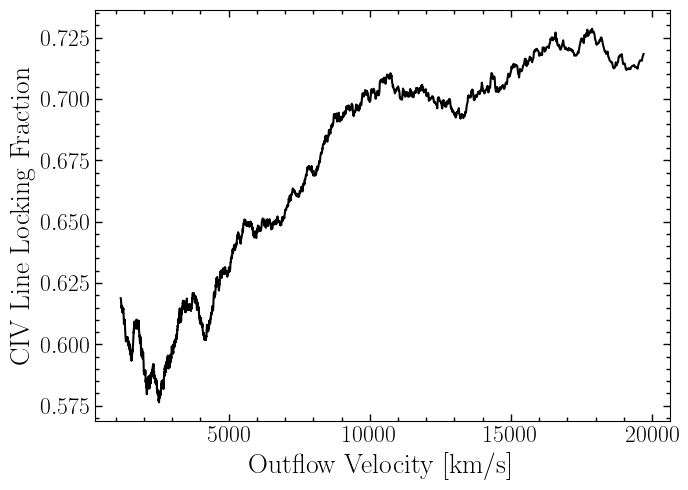

In [13]:
labelsize = 20
ticksize = 15
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(velocities, CIV_fractions, 'k-')
ax.set_ylabel(r'CIV Line Locking Fraction', fontsize=labelsize)
ax.set_xlabel(r'Outflow Velocity [km/s]', fontsize=labelsize)
ax.tick_params(axis='both', which='major', direction='in', top=True, right=True,
               length=5, width=1, labelsize=ticksize+2)
ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
               length=3, width=1)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.offsetText.set_fontsize(labelsize)
plt.tight_layout()
#plt.xscale('log')
plt.show()

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

# --- Load data ---
d = np.load('/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/CIV_relative_absorption_data.npz')

# Assume `velocities` is already defined, otherwise load or define it
# velocities = np.linspace(...)

# --- Interpolate ---
interp_func = interp1d(d['velocities'], d['relative_vals'], bounds_error=False, fill_value=np.nan)
interped_vals = interp_func(velocities)

# --- Mask valid values only ---
valid = ~np.isnan(velocities) & ~np.isnan(interped_vals)
x_data = velocities[valid]
y_data = CIV_densities/interped_vals[valid]

# --- Take last half of the data ---
half_idx = 2*len(x_data) // 3
x_fit = x_data[half_idx:]
y_fit = y_data[half_idx:]

# --- Remove or mask non-positive values (log-log fit needs > 0) ---
positive = (x_fit > 0) & (y_fit > 0)
x_fit = x_fit[positive]
y_fit = y_fit[positive]

# --- Fit power-law in log-log space ---
log_x = np.log10(x_fit)
log_y = np.log10(y_fit)

# Linear fit: log(y) = log(A) + alpha * log(x)
slope, intercept = np.polyfit(log_x, log_y, 1)
alpha = slope
A = 10**intercept

# --- Define power-law model for plotting ---
def power_law(x, A, alpha):
    return A * x**alpha

# --- Plot the results ---
plt.figure(figsize=(8, 6))
plt.plot(x_data, y_data, label='Interpolated Data', color='gray')
plt.plot(x_fit, power_law(x_fit, A, alpha), 'r--', label=fr'Fit: $y = {A:.2e} \cdot x^{{{alpha:.2f}}}$')
plt.xlabel("Velocity [km/s]", fontsize=14)
plt.ylabel("Relative Absorption", fontsize=14)
plt.tick_params(direction='in', top=True, right=True)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


TypeError: only integer scalar arrays can be converted to a scalar index

Best-fit parameters:
  v_inf = 23068.4 km/s
  beta = 0.61
 r = 3.76e+15 cm
 Mdot = 5.22e+01


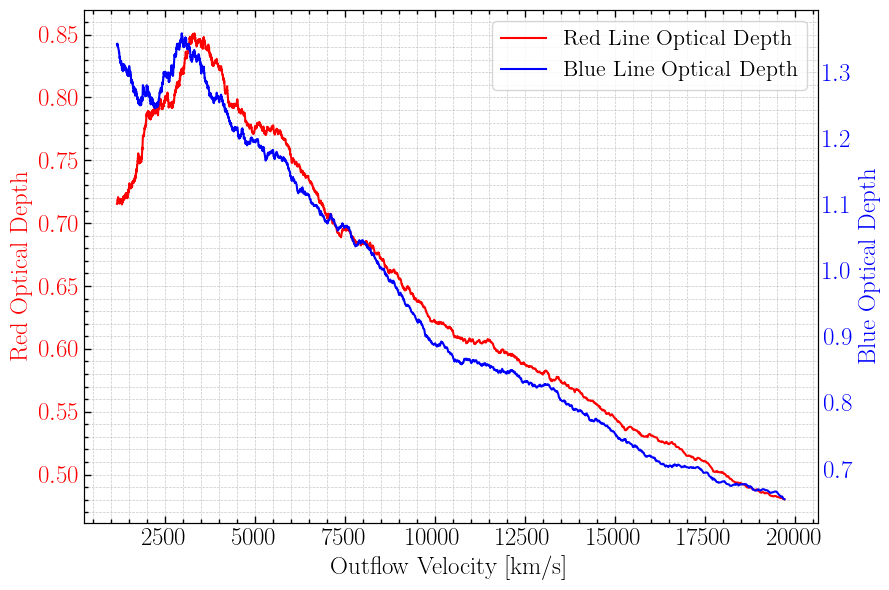

In [ ]:
# --- Input your data here ---
velocities = np.array(velocities)     # in km/s
CIV_tau = np.array(CIV_tau)        # optical depth (dimensionless)
CIV_ratios = np.array(CIV_ratios)
cutoff = 1400
Tau_blue = CIV_tau*CIV_ratios
Tau = CIV_tau


# --- Sobolev-based wind model for τ(v) ---
def sobolev_model(v, v_inf, beta, r0, Mdot):
    e = -1.602176634*10**(-19)
    f = 0.09520
    lam = 1550.770e-10
    me = 9.1093837*10**(-31)
    mp = 1.67262192*10**(-27)
    c = 299792458
    mu = 0.12
    #Mdot = 0.03*6.301034091e22

    x = (v/v_inf)**((1-2*beta)/beta)
    pre_fac = e**2*f*lam/(me*c*4*mp)
    unknowns = Mdot/(mu*r0*v_inf**2*beta)

    return pre_fac*unknowns*x


# --- Fit the model to the data ---
p0 = [30*10**6, 0.6, 10**14, 1e24]  # include initial guess for r0
bounds = ([20*10**6, 0.5, 1e13, 1e20], [50*10**6, 2.0, 1e16, 1e25])
popt, pcov = curve_fit(sobolev_model, velocities[cutoff:]*1000, Tau[cutoff:], p0=p0, bounds=bounds)


v_inf_fit, beta_fit, r_0, Mdot = popt
print(f"Best-fit parameters:\n  v_inf = {v_inf_fit/1000:.1f} km/s\n  beta = {beta_fit:.2f}\n r = {r_0*100:.2e} cm\n Mdot = {Mdot/6.301034091e22:.2e}")

# --- Generate model curve ---
v_fit = velocities[cutoff-400:]
tau_fit = sobolev_model(v_fit*1000, popt[0], popt[1], popt[2], popt[3])

labelsize = 18
ticksize = 16
fig, ax1 = plt.subplots(figsize=(9, 6))

# Primary axis: Red line (Tau)
ax1.plot(velocities, Tau, 'r-', label='Red Line Optical Depth')
ax1.set_xlabel(r'Outflow Velocity [km/s]', fontsize=labelsize)
ax1.set_ylabel(r"Red Optical Depth", color='red', fontsize=labelsize)
ax1.tick_params(axis='y', labelcolor='red')
ax1.tick_params(axis='both', which='major', direction='in', top=True, right=False,
                length=5, width=1, labelsize=ticksize+2)
ax1.tick_params(axis='both', which='minor', direction='in', top=True, right=False,
                length=3, width=1)
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())

# Add grid to primary axis
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Secondary axis: Blue line (Tau_blue)
ax2 = ax1.twinx()
ax2.plot(velocities, Tau_blue, 'b-', label='Blue Line Optical Depth')
ax2.set_ylabel(r"Blue Optical Depth", color='blue', fontsize=labelsize)
ax2.tick_params(axis='y', labelcolor='blue')
ax2.yaxis.set_minor_locator(AutoMinorLocator())
ax2.tick_params(axis='both', which='major', direction='in', top=True, right=False,
                length=5, width=1, labelsize=ticksize+2)
ax2.tick_params(axis='both', which='minor', direction='in', top=True, right=False,
                length=3, width=1)

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, fontsize=labelsize - 2, loc='upper right')

plt.tight_layout()
plt.show()


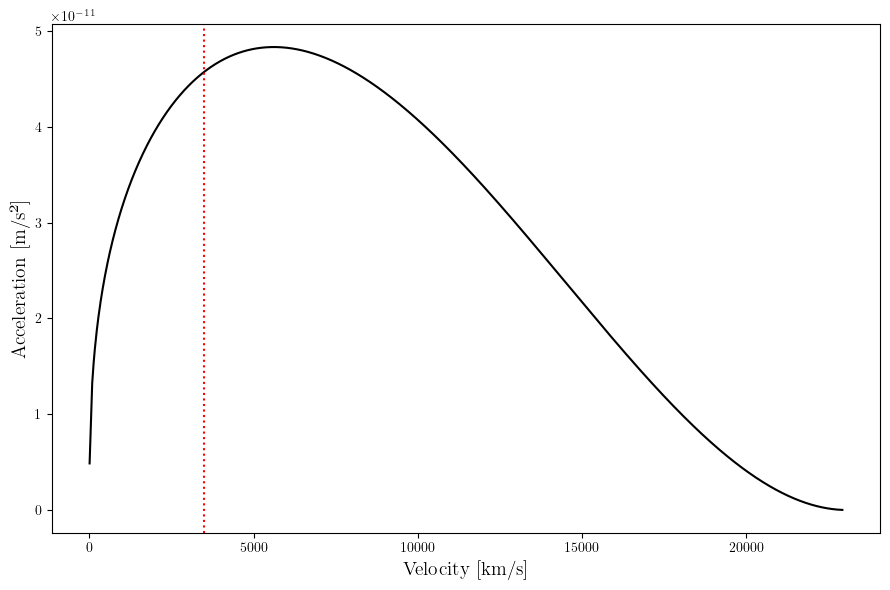

In [ ]:
# --- Best-fit parameters (from your fit) ---
v_inf = popt[0]  # m/s
beta = popt[1]
r0 = popt[3]   # meters

# --- Radius array ---
r = np.linspace(r0*1.000001, r0 * 100, 1000000)


# --- Velocity profile (m/s) ---
v = v_inf * (1 - r0 / r)**beta

# --- Derivative dv/dr ---
# dv/dr in m/s per meter
dv_dr = beta * v_inf * (1 - r0 / r)**(beta - 1) * (r0 / r**2)

# --- Acceleration ---
# a = v * dv/dr (velocity in km/s * dv/dr in km/s per m) = km²/s² per m
# Convert to m/s² for clearer physical intuition:
# 1 km = 1000 m, so multiply km²/s² by (1000 m/km)^2 = 1e6 to get m²/s²
# then divide by m to get m/s²

a = v * dv_dr  # in km²/s²/m

# --- Plotting acceleration vs velocity ---
plt.figure(figsize=(9, 6))
plt.plot(v/1000, a, 'k-')
plt.axvline(x=3500, color='r', linestyle=':', label='3,500 km/s')
plt.xlabel('Velocity [km/s]', fontsize=14)
plt.ylabel('Acceleration [m/s²]', fontsize=14)
# plt.xscale('log')
# plt.yscale('log')
plt.tight_layout()
plt.show()


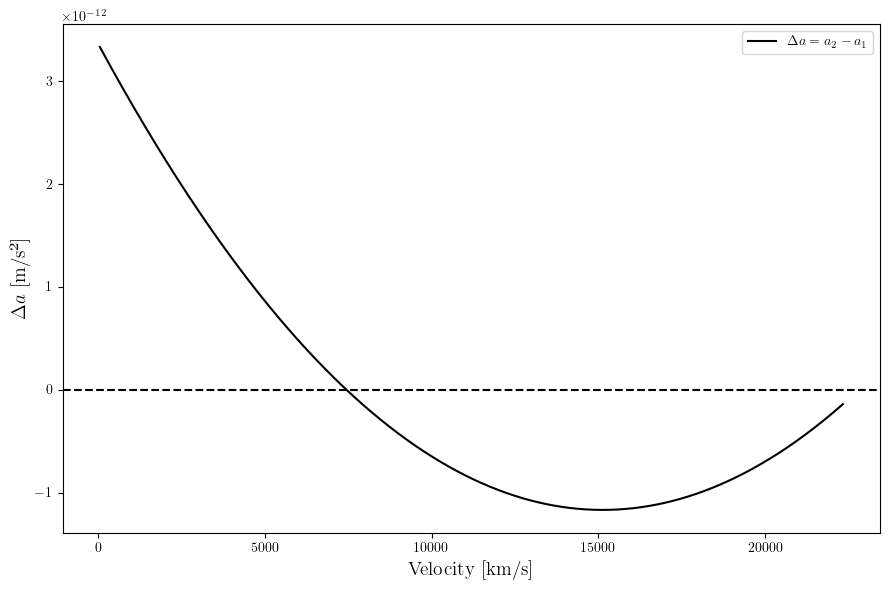

RuntimeError: latex was not able to process the following string:
b'Stable Locking (\\u0394a > 0)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmp6gb3zllh 25339aeadafbf616abdaa0b93f1ca18f2c944b6d3ef7bb1afa425ad00fb5a58f.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./25339aeadafbf616abdaa0b93f1ca18f2c944b6d3ef7bb1afa425ad00fb5a58f.tex
LaTeX2e <2024-11-01> patch level 2
L3 programming layer <2025-01-18>
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/article.cls
Document Class: article 2024/06/29 v1.4n Standard LaTeX document class
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2025/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2025/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/20

Error in callback <function _draw_all_if_interactive at 0x31c8f9760> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: latex was not able to process the following string:
b'Stable Locking (\\u0394a > 0)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpd1xxbd51 25339aeadafbf616abdaa0b93f1ca18f2c944b6d3ef7bb1afa425ad00fb5a58f.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./25339aeadafbf616abdaa0b93f1ca18f2c944b6d3ef7bb1afa425ad00fb5a58f.tex
LaTeX2e <2024-11-01> patch level 2
L3 programming layer <2025-01-18>
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/article.cls
Document Class: article 2024/06/29 v1.4n Standard LaTeX document class
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2025/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2025/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/20

RuntimeError: latex was not able to process the following string:
b'Stable Locking (\\u0394a > 0)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmp7lca_z0p 25339aeadafbf616abdaa0b93f1ca18f2c944b6d3ef7bb1afa425ad00fb5a58f.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./25339aeadafbf616abdaa0b93f1ca18f2c944b6d3ef7bb1afa425ad00fb5a58f.tex
LaTeX2e <2024-11-01> patch level 2
L3 programming layer <2025-01-18>
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/article.cls
Document Class: article 2024/06/29 v1.4n Standard LaTeX document class
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2025/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2025/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/20

<Figure size 900x600 with 1 Axes>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- Best-fit parameters (from previous fit) ---
v_inf = popt[0]  # m/s
beta = 1#popt[1]
r0 = popt[3]        # meters

# --- Radius and velocity arrays ---
r = np.linspace(r0*1.0000001, r0 * 100, 1000000)
v = v_inf * (1 - r0 / r)**beta
dv_dr = beta * v_inf * (1 - r0 / r)**(beta - 1) * (r0 / r**2)
a = v * dv_dr

# --- Interpolated acceleration as a function of velocity ---
a_interp = interp1d(v, a, bounds_error=False, fill_value=np.nan)

# --- Velocity range for Δa and ε ---
v_plot = np.linspace(50000, np.max(v) - 600, 10000)
delta_v = 500000  # m/s line-locking separation

a1 = a_interp(v_plot)               # trailing cloud
a2 = a_interp(v_plot + delta_v)     # leading cloud
delta_a = a2 - a1
epsilon = delta_a / np.abs(a2)

# Measured values for epsilon
relativeAbsorptionFilename = '/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/CIV_relative_absorption_data.npz'
RelativeAbsorptionData = np.load(relativeAbsorptionFilename)
CIV_rel_abs = np.interp(v_plot/1000, RelativeAbsorptionData['velocities'], RelativeAbsorptionData['relative_vals'])
CIV_linelocked_reduction =  np.interp(v_plot/1000, velocities, np.array(CIV_reduction))
measuredEpsilon = CIV_rel_abs*CIV_linelocked_reduction


# Masks for stable locking regions based on Milgrom's condition
stable_positive = (delta_a > 0) & (epsilon > 0)
stable_negative = (delta_a < 0) & (epsilon < 0)

# --- Plot Δa ---
plt.figure(figsize=(9, 6))
plt.plot(v_plot/1000, delta_a, 'k', label=r'$\Delta a = a_2 - a_1$')
plt.axhline(0, color='k', linestyle='--')
plt.xlabel('Velocity [km/s]', fontsize=14)
plt.ylabel(r'$\Delta a$ [m/s²]', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot ε ---
ymax = 0.4
ymin = -0
plt.figure(figsize=(9, 6))
plt.plot(v_plot/1000, np.abs(epsilon), 'k', label=r'$\epsilon = \Delta a / |a_2|$')
plt.plot(v_plot/1000, measuredEpsilon, color='blue', label=r'Calculated $\epsilon$')
# Shade above ε when Δa > 0 and ε > 0
plt.fill_between(v_plot/1000, epsilon, ymax, where=stable_positive, color='green', alpha=0.3, label='Stable Locking (Δa > 0)')
# Shade below ε when Δa < 0 and ε < 0
plt.fill_between(v_plot/1000, np.abs(epsilon), ymax, where=stable_negative, color='green', alpha=0.3, label='Stable Locking (Δa < 0)')
plt.xlabel('Velocity [km/s]', fontsize=14)
plt.ylabel(r'$\epsilon$', fontsize=14)
plt.ylim(ymin, ymax)
plt.xlim(0, 20000)
plt.legend()
plt.tight_layout()
plt.show()


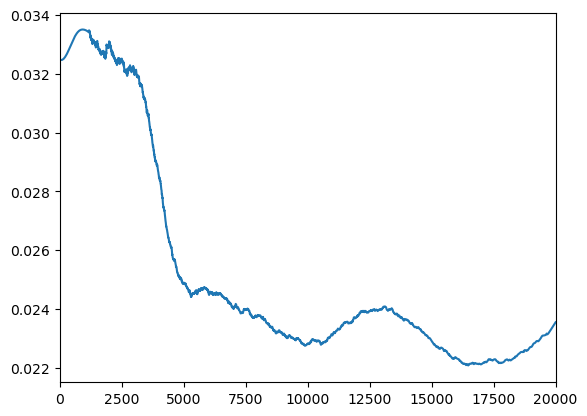

In [ ]:
plt.plot(v_plot/1000, measuredEpsilon)
plt.xlim(0, 20000)
plt.show()

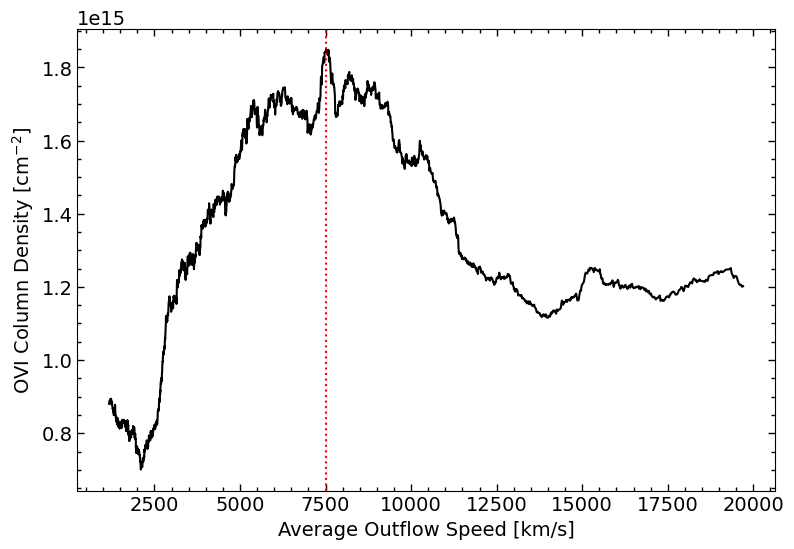

In [ ]:

# Plotting
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(velocities, OVI_densities, color='k')
ax.axvline(x=7500, color='r', linestyle=':', label='7,500 km/s')
# Axis labels and formatting
ax.set_ylabel(r'OVI Column Density [cm$^{-2}$]', fontsize=labelsize)
ax.set_xlabel(r'Average Outflow Speed [km/s]', fontsize=labelsize)
ax.tick_params(axis='both', which='major', direction='in', top=True, right=True,
               length=5, width=1, labelsize=ticksize+2)
ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
               length=3, width=1)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
# Scientific notation formatting
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax.yaxis.offsetText.set_fontsize(labelsize)
plt.show()

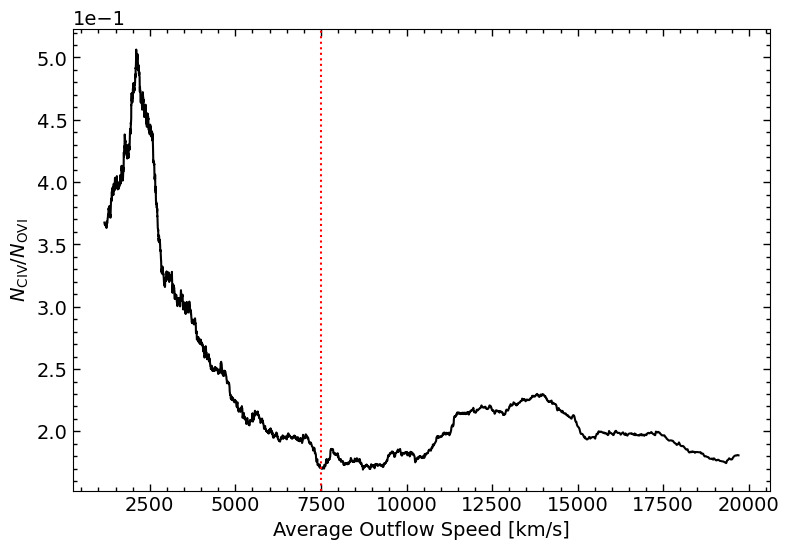

In [ ]:

# Plotting
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(velocities, np.array(CIV_densities)/np.array(OVI_densities), color='k')
ax.axvline(x=7500, color='r', linestyle=':', label='7,500 km/s')
# Axis labels and formatting
ax.set_ylabel(r'$N_{\text{CIV}} / N_{\text{OVI}}$', fontsize=labelsize)
ax.set_xlabel(r'Average Outflow Speed [km/s]', fontsize=labelsize)
ax.tick_params(axis='both', which='major', direction='in', top=True, right=True,
               length=5, width=1, labelsize=ticksize+2)
ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
               length=3, width=1)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
# Scientific notation formatting
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax.yaxis.offsetText.set_fontsize(labelsize)
plt.show()

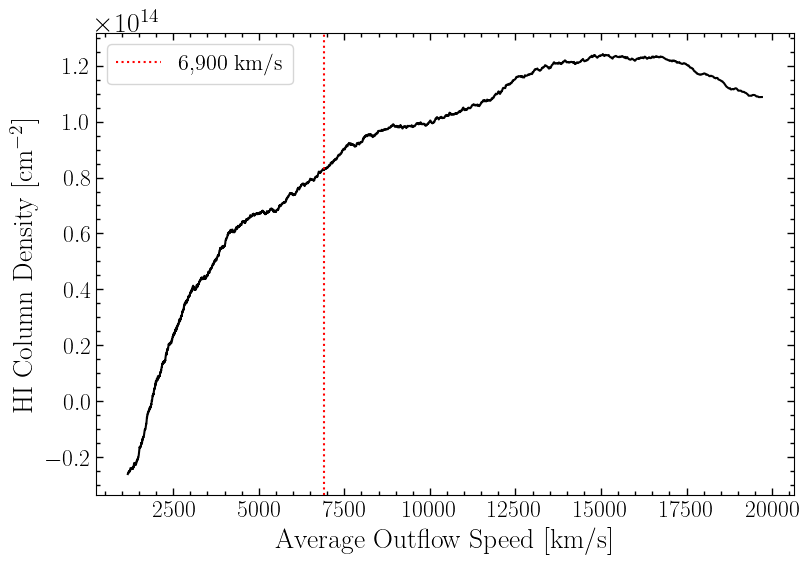

In [ ]:
# Plotting
labelsize = 20
ticksize = 15
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(velocities, HI_densities, color='k')
ax.axvline(x=6900, color='r', linestyle=':', label='6,900 km/s')
# Axis labels and formatting
ax.set_ylabel(r'HI Column Density [cm$^{-2}$]', fontsize=labelsize)
ax.set_xlabel(r'Average Outflow Speed [km/s]', fontsize=labelsize)
ax.tick_params(axis='both', which='major', direction='in', top=True, right=True,
               length=5, width=1, labelsize=ticksize+2)
ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
               length=3, width=1)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
# Scientific notation formatting
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax.yaxis.offsetText.set_fontsize(labelsize)
ax.legend(fontsize=labelsize-4)
plt.savefig("./Results/Figures/Density_vs_Velocity.png", bbox_inches="tight", dpi=300)
plt.show()

### Read in the six velocity data sets

In [ ]:
data1 = pd.read_csv(f"/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cuts/LineLocking_Stats_Final_Vel1.csv")
values1 = np.vstack([data1['Blue Depths'], data1['Red Depths'], data1['Noises'], data1['Trough Depths'], data1['Trough Widths'], data1['Triplet Depths']])
master_KDE1 = gaussian_kde(values1, bw_method=1/8)

data2 = pd.read_csv(f"/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cuts/LineLocking_Stats_Final_Vel2.csv")
values2 = np.vstack([data2['Blue Depths'], data2['Red Depths'], data2['Noises'], data2['Trough Depths'], data2['Trough Widths'], data2['Triplet Depths']])
master_KDE2 = gaussian_kde(values2, bw_method=1/8)

data3 = pd.read_csv(f"/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cuts/LineLocking_Stats_Final_Vel3.csv")
values3 = np.vstack([data3['Blue Depths'], data3['Red Depths'], data3['Noises'], data3['Trough Depths'], data3['Trough Widths'], data3['Triplet Depths']])
master_KDE3 = gaussian_kde(values3, bw_method=1/8)

data4 = pd.read_csv(f"/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cuts/LineLocking_Stats_Final_Vel4.csv")
values4 = np.vstack([data4['Blue Depths'], data4['Red Depths'], data4['Noises'], data4['Trough Depths'], data4['Trough Widths'], data4['Triplet Depths']])
master_KDE4 = gaussian_kde(values4, bw_method=1/8)

data5 = pd.read_csv(f"/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cuts/LineLocking_Stats_Final_Vel5.csv")
values5 = np.vstack([data5['Blue Depths'], data5['Red Depths'], data5['Noises'], data5['Trough Depths'], data5['Trough Widths'], data5['Triplet Depths']])
master_KDE5 = gaussian_kde(values5, bw_method=1/8)

data6 = pd.read_csv(f"/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cuts/LineLocking_Stats_Final_Vel6.csv")
values6 = np.vstack([data6['Blue Depths'], data6['Red Depths'], data6['Noises'], data6['Trough Depths'], data6['Trough Widths'], data6['Triplet Depths']])
master_KDE6 = gaussian_kde(values6, bw_method=1/8)

### Build six sets of equivelent mocks

In [ ]:
Mock_Trough_Table1 = pd.DataFrame(columns = ["Wavelengths", "Flux", "Trough Width", "Noise"])
Mock_Trough_Table2 = pd.DataFrame(columns = ["Wavelengths", "Flux", "Trough Width", "Noise"])
Mock_Trough_Table3 = pd.DataFrame(columns = ["Wavelengths", "Flux", "Trough Width", "Noise"])
Mock_Trough_Table4 = pd.DataFrame(columns = ["Wavelengths", "Flux", "Trough Width", "Noise"])
Mock_Trough_Table5 = pd.DataFrame(columns = ["Wavelengths", "Flux", "Trough Width", "Noise"])
Mock_Trough_Table6 = pd.DataFrame(columns = ["Wavelengths", "Flux", "Trough Width", "Noise"])

# Create and store thousands of mock spectra 
print(f'Creating a Sample of {data1.shape[0]} Mock Spectra...')
for k in tqdm(range(data1.shape[0])):
    shift = np.random.normal(loc=0, scale= 0.3, size = 1)[0]
    wavelengths, Flux, params = LineLocking.generate_spectra(wavelength_range=(1500+shift, 1600+shift), KDE=master_KDE1, return_params=True)
    Mock_Trough_Table1.loc[ len(Mock_Trough_Table1) ] = [wavelengths, Flux, params['Trough Width'][0], params['Noise'][0]]
# Create and store thousands of mock spectra 
print(f'Creating a Sample of {data2.shape[0]} Mock Spectra...')
for k in tqdm(range(data2.shape[0])):
    shift = np.random.normal(loc=0, scale= 0.3, size = 1)[0]
    wavelengths, Flux, params = LineLocking.generate_spectra(wavelength_range=(1500+shift, 1600+shift), KDE=master_KDE2, return_params=True)
    Mock_Trough_Table2.loc[ len(Mock_Trough_Table2) ] = [wavelengths, Flux, params['Trough Width'][0], params['Noise'][0]]
# Create and store thousands of mock spectra 
print(f'Creating a Sample of {data3.shape[0]} Mock Spectra...')
for k in tqdm(range(data3.shape[0])):
    shift = np.random.normal(loc=0, scale= 0.3, size = 1)[0]
    wavelengths, Flux, params = LineLocking.generate_spectra(wavelength_range=(1500+shift, 1600+shift), KDE=master_KDE3, return_params=True)
    Mock_Trough_Table3.loc[ len(Mock_Trough_Table3) ] = [wavelengths, Flux, params['Trough Width'][0], params['Noise'][0]]
# Create and store thousands of mock spectra 
print(f'Creating a Sample of {data4.shape[0]} Mock Spectra...')
for k in tqdm(range(data4.shape[0])):
    shift = np.random.normal(loc=0, scale= 0.3, size = 1)[0]
    wavelengths, Flux, params = LineLocking.generate_spectra(wavelength_range=(1500+shift, 1600+shift), KDE=master_KDE4, return_params=True)
    Mock_Trough_Table4.loc[ len(Mock_Trough_Table4) ] = [wavelengths, Flux, params['Trough Width'][0], params['Noise'][0]]
# Create and store thousands of mock spectra 
print(f'Creating a Sample of {data5.shape[0]} Mock Spectra...')
for k in tqdm(range(data5.shape[0])):
    shift = np.random.normal(loc=0, scale= 0.3, size = 1)[0]
    wavelengths, Flux, params = LineLocking.generate_spectra(wavelength_range=(1500+shift, 1600+shift), KDE=master_KDE5, return_params=True)
    Mock_Trough_Table5.loc[ len(Mock_Trough_Table5) ] = [wavelengths, Flux, params['Trough Width'][0], params['Noise'][0]]
# Create and store thousands of mock spectra 
print(f'Creating a Sample of {data6.shape[0]} Mock Spectra...')
for k in tqdm(range(data6.shape[0])):
    shift = np.random.normal(loc=0, scale= 0.3, size = 1)[0]
    wavelengths, Flux, params = LineLocking.generate_spectra(wavelength_range=(1500+shift, 1600+shift), KDE=master_KDE6, return_params=True)
    Mock_Trough_Table6.loc[ len(Mock_Trough_Table6) ] = [wavelengths, Flux, params['Trough Width'][0], params['Noise'][0]]

# Perform the statistics
print(f'Building up Mock Statistics...')
mock_stats1, mock_stacking_spectra1 = LineLocking.get_mock_spectra_stats(Mock_Trough_Table1)
mock_stats2, mock_stacking_spectra2 = LineLocking.get_mock_spectra_stats(Mock_Trough_Table2)
mock_stats3, mock_stacking_spectra3 = LineLocking.get_mock_spectra_stats(Mock_Trough_Table3)
mock_stats4, mock_stacking_spectra4 = LineLocking.get_mock_spectra_stats(Mock_Trough_Table4)
mock_stats5, mock_stacking_spectra5 = LineLocking.get_mock_spectra_stats(Mock_Trough_Table5)
mock_stats6, mock_stacking_spectra6 = LineLocking.get_mock_spectra_stats(Mock_Trough_Table6)
print('Finished!')

Creating a Sample of 3651 Mock Spectra...


  0%|          | 0/3651 [00:00<?, ?it/s]

Creating a Sample of 3837 Mock Spectra...


  0%|          | 0/3837 [00:00<?, ?it/s]

Creating a Sample of 3779 Mock Spectra...


...

  0%|          | 0/3779 [00:00<?, ?it/s]

  0%|          | 0/3704 [00:00<?, ?it/s]

  0%|          | 0/3672 [00:00<?, ?it/s]

  0%|          | 0/3934 [00:00<?, ?it/s]

Finished!


# Perform the stacks

In [ ]:
def nanweighted_mean(data, weights, axis=0):
    weights = np.asarray(weights)

    # Expand weights along the axis you’re averaging over
    if axis == 0 and weights.ndim == 1:
        weights = weights[:, np.newaxis]
    elif axis == 1 and weights.ndim == 1:
        weights = weights[np.newaxis, :]

    # Mask NaNs
    mask = ~np.isnan(data)
    safe_data = np.where(mask, data, 0)
    safe_weights = np.where(mask, weights, 0)

    # Weighted mean
    weighted_sum = np.sum(safe_data * safe_weights, axis=axis)
    sum_weights = np.sum(safe_weights, axis=axis)

    with np.errstate(divide='ignore', invalid='ignore'):
        mean = np.divide(weighted_sum, sum_weights)
        mean[sum_weights == 0] = np.nan

    return mean


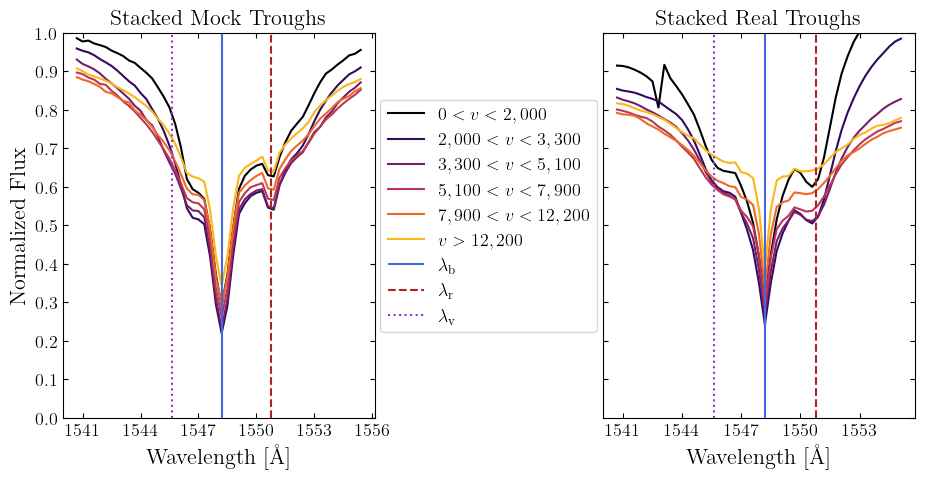

In [ ]:
#### Stack the Mock Spectra
stacked_mocks1 = np.mean(np.vstack(mock_stacking_spectra1), axis=0)
stacked_mocks2 = np.mean(np.vstack(mock_stacking_spectra2), axis=0)
stacked_mocks3 = np.mean(np.vstack(mock_stacking_spectra3), axis=0)
stacked_mocks4 = np.mean(np.vstack(mock_stacking_spectra4), axis=0)
stacked_mocks5 = np.mean(np.vstack(mock_stacking_spectra5), axis=0)
stacked_mocks6 = np.mean(np.vstack(mock_stacking_spectra6), axis=0)
stacking_wavelengths_mocks = np.arange(1548.2-25*0.3, 1548.2+25*0.3, 0.3)
#### Stack the Real Spectra
stacking_spectra_data1 = np.loadtxt(f'/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cuts/stacking_spectra_Final_Vel1.csv', delimiter=',')
stacked_spectra1 = nanweighted_mean(np.vstack(stacking_spectra_data1), data1['Weights'], axis=0)
stacking_spectra_data2 = np.loadtxt(f'/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cuts/stacking_spectra_Final_Vel2.csv', delimiter=',')
stacked_spectra2 = nanweighted_mean(np.vstack(stacking_spectra_data2), data2['Weights'], axis=0)
stacking_spectra_data3 = np.loadtxt(f'/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cuts/stacking_spectra_Final_Vel3.csv', delimiter=',')
stacked_spectra3 = nanweighted_mean(np.vstack(stacking_spectra_data3), data3['Weights'], axis=0)
stacking_spectra_data4 = np.loadtxt(f'/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cuts/stacking_spectra_Final_Vel4.csv', delimiter=',')
stacked_spectra4 = nanweighted_mean(np.vstack(stacking_spectra_data4), data4['Weights'], axis=0)
stacking_spectra_data5 = np.loadtxt(f'/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cuts/stacking_spectra_Final_Vel5.csv', delimiter=',')
stacked_spectra5 = nanweighted_mean(np.vstack(stacking_spectra_data5), data5['Weights'], axis=0)
stacking_spectra_data6 = np.loadtxt(f'/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cuts/stacking_spectra_Final_Vel6.csv', delimiter=',')
stacked_spectra6 = nanweighted_mean(np.vstack(stacking_spectra_data6), data6['Weights'], axis=0)
stacking_wavelengths = np.arange(900.2, 1599.8, 0.3)
CIV_wlMin = np.argmin(np.abs(stacking_wavelengths-stacking_wavelengths_mocks[0]))
CIV_wlMax = np.argmin(np.abs(stacking_wavelengths-stacking_wavelengths_mocks[-1]))


# Plot the Stacks
labelsize=16
ticksize = 13
cmap = plt.cm.inferno
color_indices = np.linspace(0, 1, 7)
colors = [cmap(i) for i in color_indices]
fig, axes = plt.subplots(1,2, figsize=(11., 5), sharey=True)
axes[0].plot(stacking_wavelengths_mocks, stacked_mocks1, c=colors[0])
axes[0].plot(stacking_wavelengths_mocks, stacked_mocks2, c=colors[1])
axes[0].plot(stacking_wavelengths_mocks, stacked_mocks3, c=colors[2])
axes[0].plot(stacking_wavelengths_mocks, stacked_mocks4, c=colors[3])
axes[0].plot(stacking_wavelengths_mocks, stacked_mocks5, c=colors[4])
axes[0].plot(stacking_wavelengths_mocks, stacked_mocks6, c=colors[5])
axes[0].set_xlabel(r'Wavelength [\AA]', fontsize=labelsize)
axes[0].set_ylabel('Normalized Flux', fontsize=labelsize)
axes[0].set_title('Stacked Mock Troughs', fontsize=labelsize)
axes[0].set_ylim(0.0, 1)
axes[0].set_yticks([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9, 1.0])
axes[0].set_xticks([1541,1544,1547,1550,1553,1556])
axes[0].vlines(x=1548.2, ymin=0, ymax=1, color='royalblue', linestyle='-')
axes[0].vlines(x=1550.77, ymin=0, ymax=1, color='firebrick', linestyle='--')
axes[0].vlines(x=1545.63, ymin=0, ymax=1, color='darkorchid', linestyle=':')
axes[0].tick_params(axis='both', labelsize=ticksize, direction='in', top=True, right=True)

axes[1].plot(stacking_wavelengths[CIV_wlMin:CIV_wlMax], stacked_spectra1[CIV_wlMin:CIV_wlMax], c=colors[0], label=r'$0<v<2,000$')
axes[1].plot(stacking_wavelengths[CIV_wlMin:CIV_wlMax], stacked_spectra2[CIV_wlMin:CIV_wlMax], c=colors[1], label=r'$2,000<v<3,300$')
axes[1].plot(stacking_wavelengths[CIV_wlMin:CIV_wlMax], stacked_spectra3[CIV_wlMin:CIV_wlMax], c=colors[2], label=r'$3,300<v<5,100$')
axes[1].plot(stacking_wavelengths[CIV_wlMin:CIV_wlMax], stacked_spectra4[CIV_wlMin:CIV_wlMax], c=colors[3], label=r'$5,100<v<7,900$')
axes[1].plot(stacking_wavelengths[CIV_wlMin:CIV_wlMax], stacked_spectra5[CIV_wlMin:CIV_wlMax], c=colors[4], label=r'$7,900<v<12,200$')
axes[1].plot(stacking_wavelengths[CIV_wlMin:CIV_wlMax], stacked_spectra6[CIV_wlMin:CIV_wlMax], c=colors[5], label=r'$v>12,200$')
axes[1].set_xlabel(r'Wavelength [\AA]', fontsize=labelsize)
axes[1].set_title('Stacked Real Troughs', fontsize=labelsize)
axes[1].set_ylim(0.0, 1)
axes[1].set_xticks([1541,1544,1547,1550,1553,1556])
axes[1].vlines(x=1548.2, ymin=0, ymax=1, color='royalblue', linestyle='-', label=r'$\lambda_{\mathrm{b}}$')
axes[1].vlines(x=1550.77, ymin=0, ymax=1, color='firebrick', linestyle='--', label=r'$\lambda_{\mathrm{r}}$')
axes[1].vlines(x=1545.63, ymin=0, ymax=1, color='darkorchid', linestyle=':', label=r'$\lambda_{\mathrm{v}}$')
axes[1].tick_params(axis='both', labelsize=ticksize, direction='in', top=True, right=True)
axes[1].legend(fontsize=ticksize, loc='lower right', bbox_to_anchor=(0.01, 0.2))

plt.subplots_adjust(wspace=0.73)
#plt.tight_layout()
plt.savefig("/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Results/Figures/Velocity_Stacks.png", bbox_inches="tight", dpi=300)
plt.show()


# Determine how the optical depths change with velocity

In [ ]:
Delta = 0.5     # Width of the absorption lines
C = 0.9         # Cover fraction
xc = 0.01       # Contamination Fraction
initial_guess = [0.55, 0.36, 0.5]

def beta(lam):
    global Delta
    return np.exp(-(lam-1548.20)**2/(2*Delta**2))
def alpha(lam):
    global Delta
    return np.exp(-(lam-1550.77)**2/(2*Delta**2))
def gamma(lam):
    global Delta
    return np.exp(-(lam-1545.63)**2/(2*Delta**2))

# Define the system of equations
def system_of_equations(vars):
    x, B, R = vars
    global stacked_spectra
    global stacking_wavelengths
    # Wavelengths of the blue line, red line, and violet line respectively
    lb = 1548.20
    lr = 1550.77
    lv = 1545.63
    # Measured values from the real stack of the blue line, red line, and violet line respectively 
    measured_b = np.interp(1548.20, stacking_wavelengths[CIV_wlMin:CIV_wlMax], stacked_spectra)
    measured_r = np.interp(1550.77, stacking_wavelengths[CIV_wlMin:CIV_wlMax], stacked_spectra)
    measured_v = np.interp(1545.63, stacking_wavelengths[CIV_wlMin:CIV_wlMax], stacked_spectra)
    # 3 equations that comprise the system of equations
    eq1 = x*C*B**(beta(lb))*R**(alpha(lb))*B**(gamma(lb))*R**(beta(lb))-(x+xc-1)*C*B**(beta(lb))*R**(alpha(lb))+xc*C*B**(gamma(lb))*R**(beta(lb))+1-C-measured_b
    eq2 = x*C*B**(beta(lr))*R**(alpha(lr))*B**(gamma(lr))*R**(beta(lr))-(x+xc-1)*C*B**(beta(lr))*R**(alpha(lr))+xc*C*B**(gamma(lr))*R**(beta(lr))+1-C-measured_r
    eq3 = x*C*B**(beta(lv))*R**(alpha(lv))*B**(gamma(lv))*R**(beta(lv))-(x+xc-1)*C*B**(beta(lv))*R**(alpha(lv))+xc*C*B**(gamma(lv))*R**(beta(lv))+1-C-measured_v
    return [eq1, eq2, eq3]

fractions = []
line_ratios = []
tau_red = []
tau_blue = []
stacking_spectra = [stacked_spectra1[CIV_wlMin:CIV_wlMax],
                    stacked_spectra2[CIV_wlMin:CIV_wlMax],
                    stacked_spectra3[CIV_wlMin:CIV_wlMax],
                    stacked_spectra4[CIV_wlMin:CIV_wlMax],
                    stacked_spectra5[CIV_wlMin:CIV_wlMax],
                    stacked_spectra6[CIV_wlMin:CIV_wlMax]]
for i in range(len(stacking_spectra)):
    stacked_spectra = stacking_spectra[i]
    solution = fsolve(system_of_equations, initial_guess)
    fractions.append(solution[0])
    line_ratios.append(-np.log(solution[1])/(-np.log(solution[2])))
    tau_red.append(-np.log(solution[2]))
    tau_blue.append(-np.log(solution[1]))


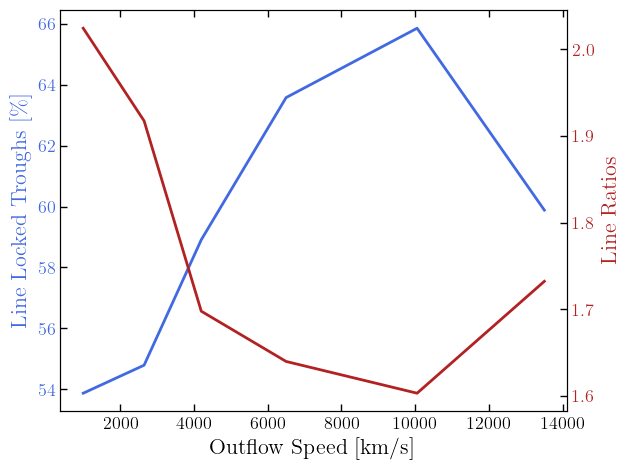

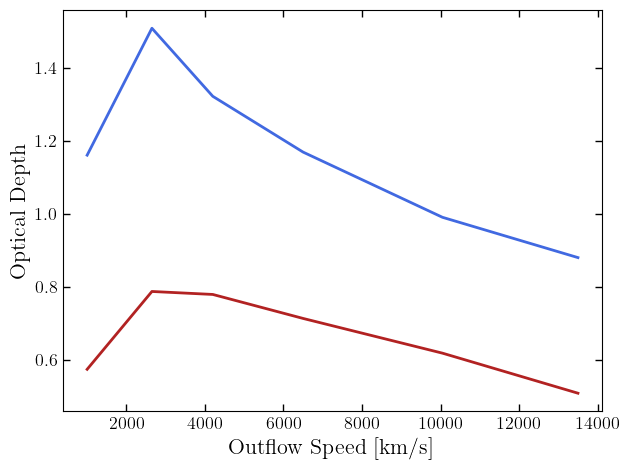

In [ ]:
velocities = np.array([1000, 2650, 4200, 6500, 10050, 13500])


fig, ax1 = plt.subplots()
# Left Y-axis
ax1.plot(velocities, [x * 100 for x in fractions], color='royalblue', label='Line Locked Troughs', lw=2)
ax1.set_xlabel(r'Outflow Speed [km/s]', fontsize=labelsize)
ax1.set_ylabel(r'Line Locked Troughs [\%]', color='royalblue', fontsize=labelsize)
# General tick settings for ax1
ax1.tick_params(axis='y', direction='in', top=True, right=True, length=5, width=1,
                labelsize=ticksize, labelcolor='royalblue')
# Explicitly set bottom x-axis ticks to black
ax1.tick_params(axis='x', direction='in', top=True, length=5, width=1,
                labelsize=ticksize, labelcolor='black', color='black')
# Right Y-axis
ax2 = ax1.twinx()
ax2.plot(velocities, line_ratios, color='firebrick', label='Line Ratios', lw=2)
ax2.set_ylabel('Line Ratios', color='firebrick', fontsize=labelsize)
ax2.tick_params(axis='y', direction='in', top=True, right=True, length=5, width=1,
                labelsize=ticksize, labelcolor='firebrick')
plt.tight_layout()
plt.show()


plt.plot(velocities, tau_blue, color='royalblue', label=r'$\tau_b$', lw=2)
plt.plot(velocities, tau_red, color='firebrick', label=r'$\tau_b$', lw=2)
plt.xlabel(r'Outflow Speed [km/s]', fontsize=labelsize)
plt.ylabel(r'Optical Depth', fontsize=labelsize)
# General tick settings for ax1
plt.tick_params(axis='y', direction='in', top=True, right=True, length=5, width=1,
                labelsize=ticksize)
# Explicitly set bottom x-axis ticks to black
plt.tick_params(axis='x', direction='in', top=True, length=5, width=1,
                labelsize=ticksize, labelcolor='black', color='black')
plt.tight_layout()
plt.show()

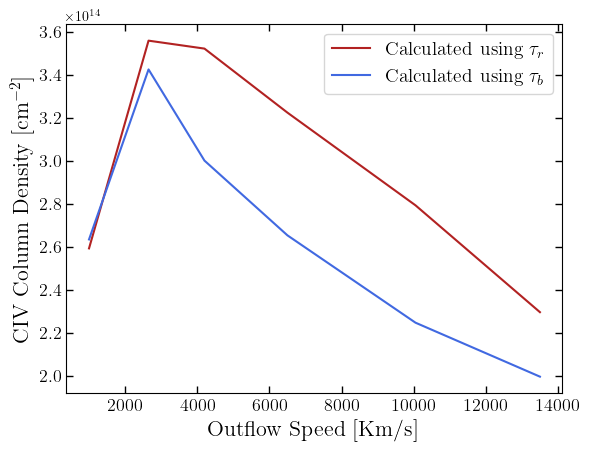

In [ ]:
red_Density = []
for tau in tau_red:
    red_Density.append(LineLocking.column_density_from_tau(tau, 1551).value)

blue_Density = []
for tau in tau_blue:
    blue_Density.append(LineLocking.column_density_from_tau(tau, 1548).value)

plt.plot(velocities, red_Density, c='firebrick', label=r'Calculated using $\tau_r$')
plt.plot(velocities, blue_Density, c='royalblue', label=r'Calculated using $\tau_b$')
plt.xlabel(r'Outflow Speed [Km/s]', fontsize=labelsize)
plt.ylabel(r'CIV Column Density [cm$^{-2}$]', fontsize=labelsize)
# General tick settings for ax1
plt.tick_params(axis='y', direction='in', top=True, right=True, length=5, width=1,
                labelsize=ticksize)
# Explicitly set bottom x-axis ticks to black
plt.tick_params(axis='x', direction='in', top=True, length=5, width=1,
                labelsize=ticksize, labelcolor='black', color='black')
plt.legend(fontsize=labelsize-2)
plt.show()

# Calculate the CIII Column Density

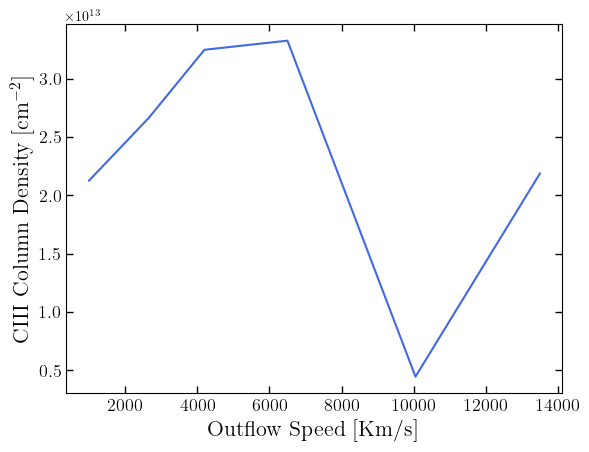

In [ ]:
def make_line(x, m, Ypoint, Xpoint):
    b = Ypoint-Xpoint*m
    return x*m+b

CIII_minn = np.argmin(np.abs(stacking_wavelengths-930))
CIII_maxx = np.argmin(np.abs(stacking_wavelengths-1050))
CIII_Smooth1 = make_line(stacking_wavelengths, +0.011, 0.61, 968)
CIII_Smooth2 = make_line(stacking_wavelengths, +0.008, 0.61, 969)
CIII_Smooth3 = make_line(stacking_wavelengths, +0.0028, 0.635, 968)
CIII_Smooth4 = make_line(stacking_wavelengths, +0.0028, 0.58, 968)
CIII_Smooth5 = make_line(stacking_wavelengths, +0.002, 0.51, 968)
CIII_Smooth6 = make_line(stacking_wavelengths, +0.007, 0.35, 968)


CIII_wls = stacking_wavelengths[CIII_minn:CIII_maxx]
CIII_stack1 = stacked_spectra1[CIII_minn:CIII_maxx]/CIII_Smooth1[CIII_minn:CIII_maxx]
CIII_stack2 = stacked_spectra2[CIII_minn:CIII_maxx]/CIII_Smooth2[CIII_minn:CIII_maxx]
CIII_stack3 = stacked_spectra3[CIII_minn:CIII_maxx]/CIII_Smooth3[CIII_minn:CIII_maxx]
CIII_stack4 = stacked_spectra4[CIII_minn:CIII_maxx]/CIII_Smooth4[CIII_minn:CIII_maxx]
CIII_stack5 = stacked_spectra5[CIII_minn:CIII_maxx]/CIII_Smooth5[CIII_minn:CIII_maxx]
CIII_stack6 = stacked_spectra6[CIII_minn:CIII_maxx]/CIII_Smooth6[CIII_minn:CIII_maxx]


def get_depths(bBar, C):
    return -np.log((bBar-1+C)/C)

Delta = 0.5
C=0.9
bBar1 = np.interp(977.0201, CIII_wls, CIII_stack1)
tb1 = get_depths(bBar1, C)
bBar2 = np.interp(977.0201, CIII_wls, CIII_stack2)
tb2 = get_depths(bBar2, C)
bBar3 = np.interp(977.0201, CIII_wls, CIII_stack3)
tb3 = get_depths(bBar3, C)
bBar4 = np.interp(977.0201, CIII_wls, CIII_stack4)
tb4 = get_depths(bBar4, C)
bBar5 = np.interp(977.0201, CIII_wls, CIII_stack5)
tb5 = get_depths(bBar5, C)
bBar6 = np.interp(977.0201, CIII_wls, CIII_stack6)
tb6 = get_depths(bBar6, C)


CIII_column_density1 = LineLocking.column_density_from_tau(tb1, 977)
CIII_column_density2 = LineLocking.column_density_from_tau(tb2, 977)
CIII_column_density3 = LineLocking.column_density_from_tau(tb3, 977)
CIII_column_density4 = LineLocking.column_density_from_tau(tb4, 977)
CIII_column_density5 = LineLocking.column_density_from_tau(tb5, 977)
CIII_column_density6 = LineLocking.column_density_from_tau(tb6, 977)
CIII_column_densities = [CIII_column_density1.value,
                         CIII_column_density2.value,
                         CIII_column_density3.value,
                         CIII_column_density4.value,
                         CIII_column_density5.value,
                         CIII_column_density6.value]

plt.plot(velocities, CIII_column_densities, c='royalblue', label=r'Calculated using $\tau_b$')
plt.xlabel(r'Outflow Speed [Km/s]', fontsize=labelsize)
plt.ylabel(r'CIII Column Density [cm$^{-2}$]', fontsize=labelsize)
# General tick settings for ax1
plt.tick_params(axis='y', direction='in', top=True, right=True, length=5, width=1,
                labelsize=ticksize)
# Explicitly set bottom x-axis ticks to black
plt.tick_params(axis='x', direction='in', top=True, length=5, width=1,
                labelsize=ticksize, labelcolor='black', color='black')
plt.show()

# Calculate the Ratio

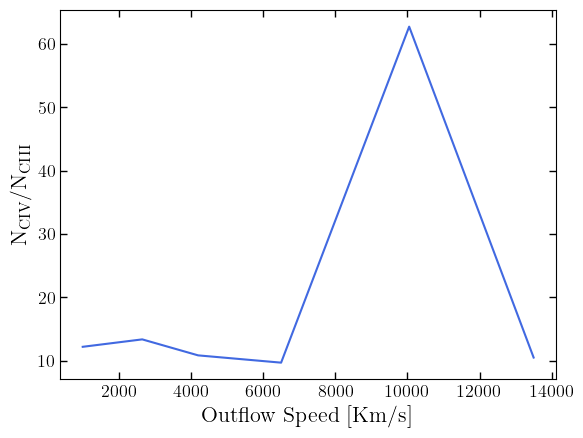

In [ ]:
plt.plot(velocities, np.array(red_Density)/np.array(CIII_column_densities), c='royalblue', label=r'Calculated using $\tau_b$')
plt.xlabel(r'Outflow Speed [Km/s]', fontsize=labelsize)
plt.ylabel(r'N$_{\mathrm{CIV}}$/N$_{\mathrm{CIII}}$', fontsize=labelsize)
# General tick settings for ax1
plt.tick_params(axis='y', direction='in', top=True, right=True, length=5, width=1,
                labelsize=ticksize)
# Explicitly set bottom x-axis ticks to black
plt.tick_params(axis='x', direction='in', top=True, length=5, width=1,
                labelsize=ticksize, labelcolor='black', color='black')
plt.show()

# Calculate the NV Column Density

python(23529) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(23530) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


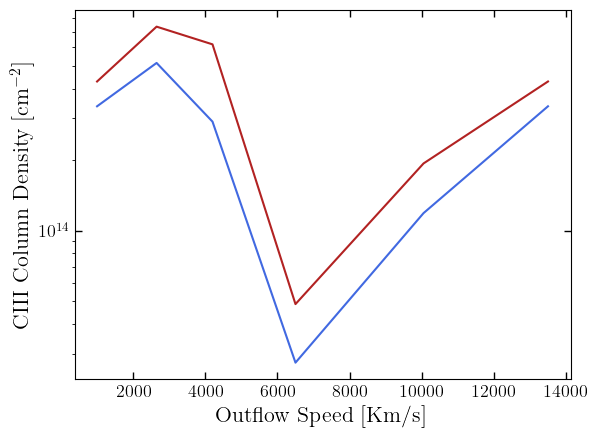

In [ ]:
NV_minn = np.argmin(np.abs(stacking_wavelengths-1225))
NV_maxx = np.argmin(np.abs(stacking_wavelengths-1255))
NV_Smooth1 = make_line(stacking_wavelengths, -0.053, 1.51, 1248)
NV_Smooth2 = make_line(stacking_wavelengths, -0.048, 1.65, 1250)
NV_Smooth3 = make_line(stacking_wavelengths, -0.03, 1.89, 1250)
NV_Smooth4 = make_line(stacking_wavelengths, 0.02, 2.06, 1250)
NV_Smooth5 = make_line(stacking_wavelengths, 0.06, 1.79, 1250)
NV_Smooth6 = make_line(stacking_wavelengths, 0.022, 0.97, 1250)


NV_wls = stacking_wavelengths[NV_minn:NV_maxx]
NV_stack1 = stacked_spectra1[NV_minn:NV_maxx]/NV_Smooth1[NV_minn:NV_maxx]
NV_stack2 = stacked_spectra2[NV_minn:NV_maxx]/NV_Smooth2[NV_minn:NV_maxx]
NV_stack3 = stacked_spectra3[NV_minn:NV_maxx]/NV_Smooth3[NV_minn:NV_maxx]
NV_stack4 = stacked_spectra4[NV_minn:NV_maxx]/NV_Smooth4[NV_minn:NV_maxx]
NV_stack5 = stacked_spectra5[NV_minn:NV_maxx]/NV_Smooth5[NV_minn:NV_maxx]
NV_stack6 = stacked_spectra6[NV_minn:NV_maxx]/NV_Smooth6[NV_minn:NV_maxx]


def get_depths(rBar, bBar, C, Delta):
    lr=1242.804
    lb=1238.821
    alpha = -(lr-lb)**2/(2*Delta**2)
    tb = (np.log((bBar-1+C)/C)-np.exp(alpha)*np.log((rBar-1+C)/C))/(np.exp(2*alpha)-1)
    tr = -tb*np.exp(alpha)-np.log((rBar-1+C)/C)
    return tb, tr

Delta = 0.5
C=0.9
rBar1 = np.interp(1242.804, NV_wls, NV_stack1)
bBar1 = np.interp(1238.821, NV_wls, NV_stack1)
tb1, tr1 = get_depths(rBar1, bBar1, C, Delta)
rBar2 = np.interp(1242.804, NV_wls, NV_stack2)
bBar2 = np.interp(1238.821, NV_wls, NV_stack2)
tb2, tr2 = get_depths(rBar2, bBar2, C, Delta)
rBar3 = np.interp(1242.804, NV_wls, NV_stack3)
bBar3 = np.interp(1238.821, NV_wls, NV_stack3)
tb3, tr3 = get_depths(rBar3, bBar3, C, Delta)
rBar4 = np.interp(1242.804, NV_wls, NV_stack4)
bBar4 = np.interp(1238.821, NV_wls, NV_stack4)
tb4, tr4 = get_depths(rBar4, bBar4, C, Delta)
rBar5 = np.interp(1242.804, NV_wls, NV_stack5)
bBar5 = np.interp(1238.821, NV_wls, NV_stack5)
tb5, tr5 = get_depths(rBar5, bBar5, C, Delta)
rBar6 = np.interp(1242.804, NV_wls, NV_stack6)
bBar6 = np.interp(1238.821, NV_wls, NV_stack6)
tb6, tr6 = get_depths(rBar1, bBar1, C, Delta)


NVred_column_density1 = LineLocking.column_density_from_tau(tr1, 1243)
NVred_column_density2 = LineLocking.column_density_from_tau(tr2, 1243)
NVred_column_density3 = LineLocking.column_density_from_tau(tr3, 1243)
NVred_column_density4 = LineLocking.column_density_from_tau(tr4, 1243)
NVred_column_density5 = LineLocking.column_density_from_tau(tr5, 1243)
NVred_column_density6 = LineLocking.column_density_from_tau(tr6, 1243)
NVred_column_densities = [NVred_column_density1.value,
                         NVred_column_density2.value,
                         NVred_column_density3.value,
                         NVred_column_density4.value,
                         NVred_column_density5.value,
                         NVred_column_density6.value]
NVblue_column_density1 = LineLocking.column_density_from_tau(tb1, 1239)
NVblue_column_density2 = LineLocking.column_density_from_tau(tb2, 1239)
NVblue_column_density3 = LineLocking.column_density_from_tau(tb3, 1239)
NVblue_column_density4 = LineLocking.column_density_from_tau(tb4, 1239)
NVblue_column_density5 = LineLocking.column_density_from_tau(tb5, 1239)
NVblue_column_density6 = LineLocking.column_density_from_tau(tb6, 1239)
NVblue_column_densities = [NVblue_column_density1.value,
                         NVblue_column_density2.value,
                         NVblue_column_density3.value,
                         NVblue_column_density4.value,
                         NVblue_column_density5.value,
                         NVblue_column_density6.value]

plt.plot(velocities, NVblue_column_densities, c='royalblue', label=r'Calculated using $\tau_b$')
plt.plot(velocities, NVred_column_densities, c='firebrick', label=r'Calculated using $\tau_r$')
plt.xlabel(r'Outflow Speed [Km/s]', fontsize=labelsize)
plt.ylabel(r'CIII Column Density [cm$^{-2}$]', fontsize=labelsize)
# General tick settings for ax1
plt.tick_params(axis='y', direction='in', top=True, right=True, length=5, width=1,
                labelsize=ticksize)
# Explicitly set bottom x-axis ticks to black
plt.tick_params(axis='x', direction='in', top=True, length=5, width=1,
                labelsize=ticksize, labelcolor='black', color='black')
plt.yscale('log')
plt.show()

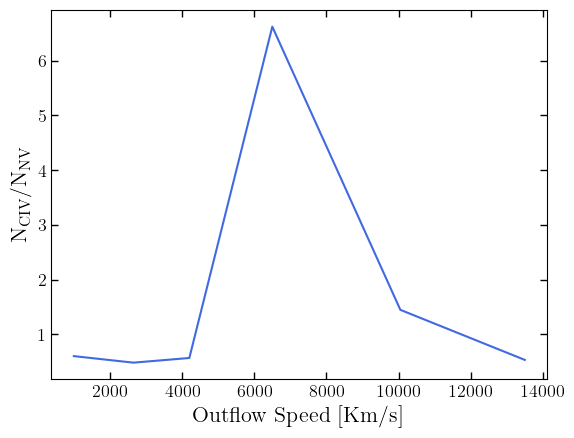

In [ ]:
plt.plot(velocities, np.array(red_Density)/np.array(NVred_column_densities), c='royalblue', label=r'Calculated using $\tau_b$')
plt.xlabel(r'Outflow Speed [Km/s]', fontsize=labelsize)
plt.ylabel(r'N$_{\mathrm{CIV}}$/N$_{\mathrm{NV}}$', fontsize=labelsize)
# General tick settings for ax1
plt.tick_params(axis='y', direction='in', top=True, right=True, length=5, width=1,
                labelsize=ticksize)
# Explicitly set bottom x-axis ticks to black
plt.tick_params(axis='x', direction='in', top=True, length=5, width=1,
                labelsize=ticksize, labelcolor='black', color='black')
plt.show()

In [ ]:
CIV_rel_abs*CIV_linelocked_reduction

NameError: name 'CIV_rel_abs' is not defined